In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [70]:
df = pd.read_csv("data/par-to-par-subset.csv")

for col in ["DATE_FROM", "DATE_TO"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df.head()

,CELEX_FROM,TITLE_FROM,NUMBER_FROM,DATE_FROM,TEXT_FROM,CELEX_TO,TITLE_TO,NUMBER_TO,TEXT_TO,DATE_TO
0,61985CJ0341,Erik van der Stijl and Geoffrey Cullington v C...,18,1989-02-28,18 Those arguments need not be addressed . As ...,61976CJ0030,Berthold Küster v European Parliament.,8,8 IT CANNOT BE CONTESTED THAT THOSE TO WHOM A ...,1976-11-25
1,61985CJ0341,Erik van der Stijl and Geoffrey Cullington v C...,51,1989-02-28,51 The Court held in its judgment of 30 Octobe...,61973CJ0188,Daniele Grassi v Council of the European Commu...,38,"38 IN FACT, THOUGH THE APPOINTING AUTHORITY HA...",1974-10-30
2,61986CJ0062,AKZO Chemie BV v Commission of the European Co...,16,1991-07-03,"16 In that respect it should be observed that,...",61982CJ0043,Vereniging ter Bevordering van het Vlaamse Boe...,25,25 IN THAT CONNECTION IT MUST BE OBSERVED THAT...,1984-01-17
3,61986CJ0062,AKZO Chemie BV v Commission of the European Co...,51,1991-07-03,51 In its judgment in Case 31/80 L' Oréal v De...,61980CJ0031,"NV L'Oréal and SA L'Oréal v PVBA ""De Nieuwe AM...",25,25 AS THE COURT EMPHASIZED IN ITS JUDGMENT OF ...,1980-12-11
4,61986CJ0062,AKZO Chemie BV v Commission of the European Co...,60,1991-07-03,60 With regard to market shares the Court has ...,61976CJ0085,Hoffmann-La Roche & Co. AG v Commission of the...,41,41FURTHERMORE ALTHOUGH THE IMPORTANCE OF THE M...,1979-02-13


In [71]:
df.isna().sum()

CELEX_FROM       0
TITLE_FROM       0
NUMBER_FROM      0
DATE_FROM        0
TEXT_FROM       53
CELEX_TO         0
TITLE_TO         0
NUMBER_TO        0
TEXT_TO        142
DATE_TO          0
dtype: int64

In [72]:
count_before = len(df)

# Remove rows with missing values
df = df.dropna()
print(f"Removed {count_before - len(df)} rows with missing values")

count_before = len(df)

# Remove duplicates
df = df.drop_duplicates()
print(f"Removed {count_before - len(df)} duplicates")

Removed 195 rows with missing values
Removed 0 duplicates


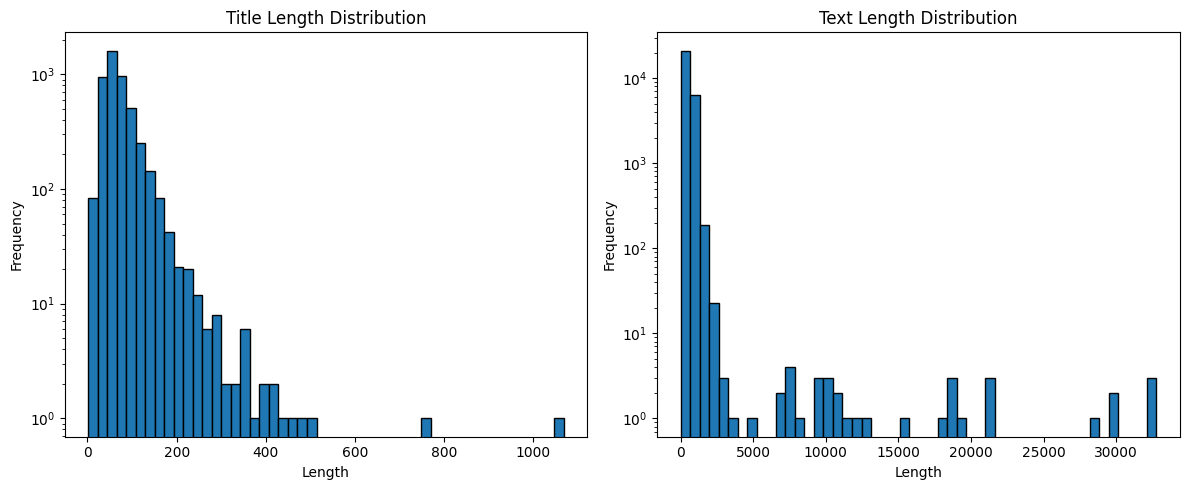

In [73]:
# Get unique nodes for titles
titles = pd.concat([df['TITLE_FROM'], df['TITLE_TO']]).dropna().unique()
title_lengths = pd.Series(titles).str.len()

# Get unique nodes for texts
texts = pd.concat([df['TEXT_FROM'], df['TEXT_TO']]).dropna().unique()
text_lengths = pd.Series(texts).str.len()

# Plot distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(title_lengths, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Title Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(text_lengths, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Text Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [74]:
# Create a table of statistics for title and text lengths
stats_data = {
    'Field': ['Title', 'Text'],
    'Mean': [
        title_lengths.mean(),
        text_lengths.mean()
    ],
    'Median': [
        title_lengths.median(),
        text_lengths.median()
    ],
    'Std Dev': [
        title_lengths.std(),
        text_lengths.std()
    ],
    'Min': [
        title_lengths.min(),
        text_lengths.min()
    ],
    'Max': [
        title_lengths.max(),
        text_lengths.max()
    ]
}

stats_df = pd.DataFrame(stats_data)
display(stats_df.round(2))

,Field,Mean,Median,Std Dev,Min,Max
0,Title,72.44,62.0,45.81,2,1068
1,Text,536.13,475.0,658.99,8,32767


In [75]:
texts[text_lengths >= 30000][0][-100:]

' Articles 11, 12 and 17, towards the institution that he is supposed to serve. That would destroy th'

In [76]:
titles[title_lengths <= 2]

array(['K.', 'C.', 'A.', 'X.'], dtype=object)

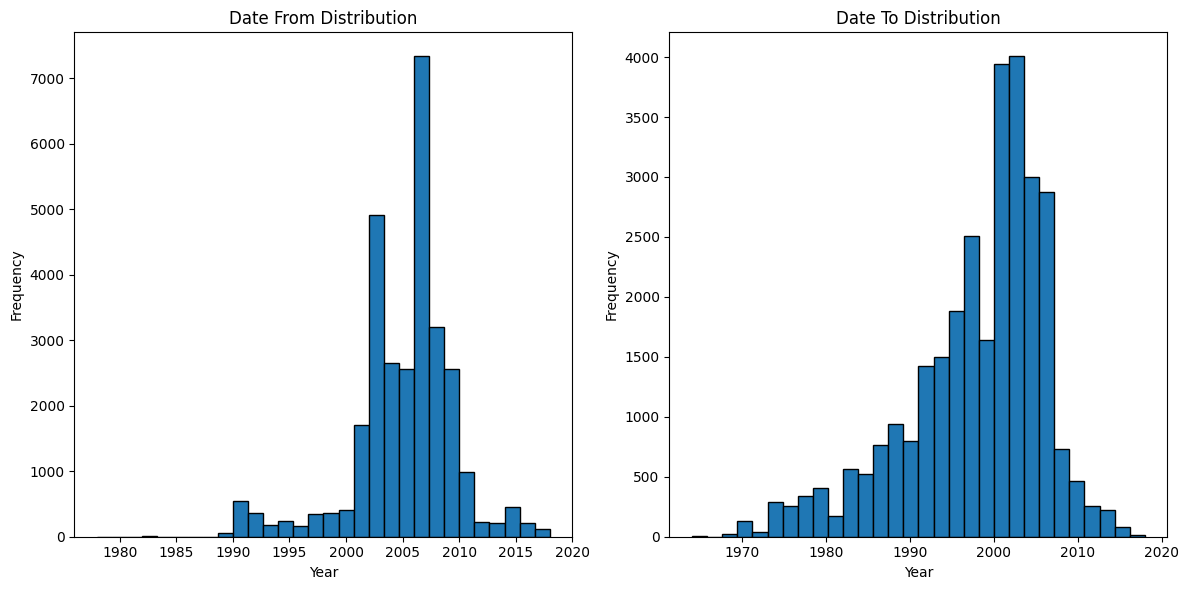

In [77]:
# Plot DATE_FROM and DATE_TO distribution
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(pd.to_datetime(df['DATE_FROM']).dt.year, bins=30, edgecolor='black')
plt.title('Date From Distribution')
plt.xlabel('Year')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(pd.to_datetime(df['DATE_TO']).dt.year, bins=30, edgecolor='black')
plt.title('Date To Distribution')
plt.xlabel('Year')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

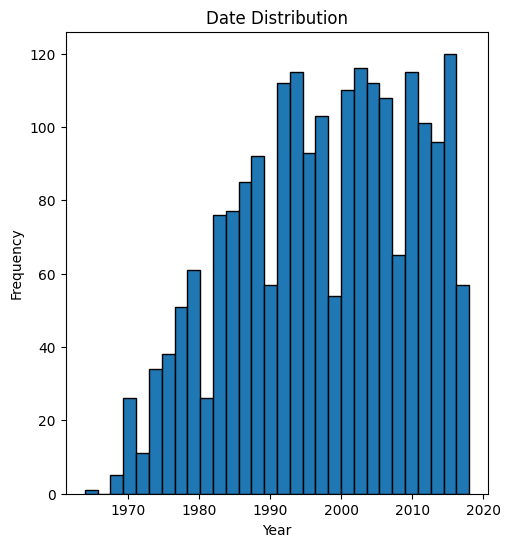

In [78]:
# Plot DATE_FROM and DATE_TO distribution
plt.figure(figsize=(12, 6))

dates = pd.concat([df['DATE_FROM'], df['DATE_TO']]).dropna().unique()
date_years = pd.to_datetime(pd.Series(dates)).dt.year

plt.subplot(1, 2, 1)
plt.hist(date_years, bins=30, edgecolor='black')
plt.title('Date Distribution')
plt.xlabel('Year')
plt.ylabel('Frequency')

In [81]:
# Imports
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Build paragraph-level node ids
df["PAR_FROM"] = df["CELEX_FROM"].astype(str) + "§" + df["NUMBER_FROM"].astype(str)
df["PAR_TO"]   = df["CELEX_TO"].astype(str)   + "§" + df["NUMBER_TO"].astype(str)

# ---- BASIC STATS ----
n_edges = len(df)
n_unique_paragraph_nodes = pd.Index(pd.concat([df["PAR_FROM"], df["PAR_TO"]])).nunique()
n_unique_case_nodes = pd.Index(pd.concat([df["CELEX_FROM"], df["CELEX_TO"]])).nunique()
n_unique_case_pairs = df[["CELEX_FROM","CELEX_TO"]].drop_duplicates().shape[0]
n_unique_paragraph_pairs = df[["PAR_FROM","PAR_TO"]].drop_duplicates().shape[0]
n_self_case_edges = (df["CELEX_FROM"] == df["CELEX_TO"]).sum()

# Duplicate edges count (exact row duplicates on PAR_FROM->PAR_TO)
duplicate_edges = n_edges - n_unique_paragraph_pairs

# ---- TEMPORAL STATS ----
valid_temporal = (df["DATE_FROM"] >= df["DATE_TO"]).sum()
invalid_temporal = (df["DATE_FROM"] < df["DATE_TO"]).sum()
equal_dates = (df["DATE_FROM"] == df["DATE_TO"]).sum()

basic_stats = pd.DataFrame([{
    "edges": n_edges,
    "unique_paragraph_nodes": n_unique_paragraph_nodes,
    "unique_case_nodes": n_unique_case_nodes,
    "unique_paragraph_pairs": n_unique_paragraph_pairs,
    "unique_case_pairs": n_unique_case_pairs,
    "duplicate_edges_paragraph_level": duplicate_edges,
    "self_case_edges": n_self_case_edges,
    "temporal_ok (DATE_FROM>=DATE_TO)": valid_temporal,
    "temporal_violations (DATE_FROM<DATE_TO)": invalid_temporal,
    "equal_dates": equal_dates
}])
basic_stats

,edges,unique_paragraph_nodes,unique_case_nodes,unique_paragraph_pairs,unique_case_pairs,duplicate_edges_paragraph_level,self_case_edges,temporal_ok (DATE_FROM>=DATE_TO),temporal_violations (DATE_FROM<DATE_TO),equal_dates
0,29805,27759,6139,29805,18278,0,2,29804,1,150


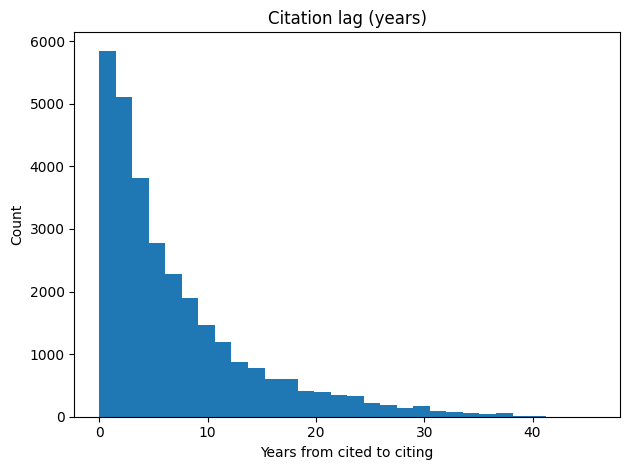

,lag_mean_years,lag_median_years,lag_p90_years,lag_max_years
0,7.09,4.62,17.23,45.78


In [104]:
# Citation lag in years (only when both dates present)
mask_dates = df["DATE_FROM"].notna() & df["DATE_TO"].notna()
lags_years = (df.loc[mask_dates, "DATE_FROM"] - df.loc[mask_dates, "DATE_TO"]).dt.days / 365.25
lags_years = lags_years[lags_years >= 0]  # keep only non-negative lags
lag_summary = {
    "count": int(lags_years.shape[0]),
    "mean_years": float(lags_years.mean()) if lags_years.shape[0] else np.nan,
    "median_years": float(lags_years.median()) if lags_years.shape[0] else np.nan,
    "p10": float(lags_years.quantile(0.10)) if lags_years.shape[0] else np.nan,
    "p25": float(lags_years.quantile(0.25)) if lags_years.shape[0] else np.nan,
    "p75": float(lags_years.quantile(0.75)) if lags_years.shape[0] else np.nan,
    "p90": float(lags_years.quantile(0.90)) if lags_years.shape[0] else np.nan,
    "max_years": float(lags_years.max()) if lags_years.shape[0] else np.nan,
}

plt.figure()
plt.hist(lags_years, bins=30)
plt.title("Citation lag (years)")
plt.xlabel("Years from cited to citing")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

pd.DataFrame([{
    "lag_mean_years": round(lag_summary["mean_years"], 2) if not np.isnan(lag_summary["mean_years"]) else np.nan,
    "lag_median_years": round(lag_summary["median_years"], 2) if not np.isnan(lag_summary["median_years"]) else np.nan,
    "lag_p90_years": round(lag_summary["p90"], 2) if not np.isnan(lag_summary["p90"]) else np.nan,
    "lag_max_years": round(lag_summary["max_years"], 2) if not np.isnan(lag_summary["max_years"]) else np.nan,
}])


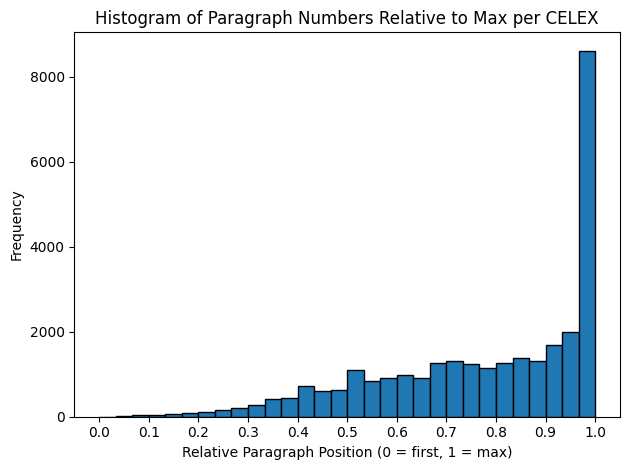

In [ ]:
# Normalize NUMBER_TO by its CELEX_TO max
df["NUMBER_TO_RATIO"] = df["NUMBER_TO"] / df.groupby("CELEX_TO")["NUMBER_TO"].transform("max")

# Plot histogram of ratios
plt.figure()
plt.hist(df["NUMBER_TO_RATIO"], bins=30, range=(0, 1), edgecolor='black')
plt.title("Histogram of Paragraph Numbers Relative to Max per CELEX")
plt.xlabel("Relative Paragraph Position (0 = first, 1 = max)")
plt.ylabel("Frequency")
plt.xticks([i/10 for i in range(11)])  # ticks at 0.0, 0.1, ..., 1.0
plt.tight_layout()
plt.show()

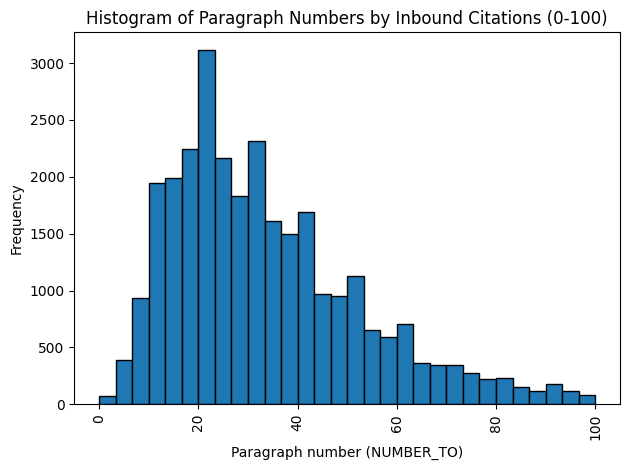

In [99]:
number_to_counts = df["NUMBER_TO"].value_counts().sort_index()

plt.figure()
plt.hist(df["NUMBER_TO"], bins=30, range=(0, 100), edgecolor='black')
plt.title("Histogram of Paragraph Numbers by Inbound Citations (0-100)")
plt.xlabel("Paragraph number (NUMBER_TO)")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [105]:
# ---- BUILD GRAPHS ----
# Paragraph-level graph
G_par = nx.DiGraph()
G_par.add_edges_from(zip(df["PAR_FROM"], df["PAR_TO"]))

# Case-level graph (collapse)
case_pairs = df.groupby(["CELEX_FROM","CELEX_TO"]).size().rename("weight").reset_index()
G_case = nx.DiGraph()
for _, row in case_pairs.iterrows():
    G_case.add_edge(row["CELEX_FROM"], row["CELEX_TO"], weight=int(row["weight"]))

# ---- DEGREE STATS ----
def degree_stats(G):
    indeg = dict(G.in_degree())
    outdeg = dict(G.out_degree())
    deg_series = pd.Series(indeg, name="in_degree").to_frame()
    deg_series["out_degree"] = pd.Series(outdeg)
    deg_series["total_degree"] = deg_series["in_degree"] + deg_series["out_degree"]
    summary = {
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "density": float(nx.density(G)),
        "mean_in": float(deg_series["in_degree"].mean()),
        "median_in": float(deg_series["in_degree"].median()),
        "p90_in": float(deg_series["in_degree"].quantile(0.90)),
        "max_in": int(deg_series["in_degree"].max()),
        "mean_out": float(deg_series["out_degree"].mean()),
        "median_out": float(deg_series["out_degree"].median()),
        "p90_out": float(deg_series["out_degree"].quantile(0.90)),
        "max_out": int(deg_series["out_degree"].max()),
    }
    top_in = deg_series.sort_values("in_degree", ascending=False).head(15).reset_index().rename(columns={"index":"node"})
    top_out = deg_series.sort_values("out_degree", ascending=False).head(15).reset_index().rename(columns={"index":"node"})
    return deg_series, summary, top_in, top_out

par_deg_df, par_summary, par_top_in, par_top_out = degree_stats(G_par)
case_deg_df, case_summary, case_top_in, case_top_out = degree_stats(G_case)

# ---- RECIPROCITY & COMPONENTS ----
def reciprocity_and_components(G):
    # reciprocity as fraction of edges with reverse
    m = G.number_of_edges()
    reciprocal = sum(1 for u,v in G.edges() if G.has_edge(v,u))
    reciprocity_frac = reciprocal / m if m else np.nan

    # Weakly & strongly connected components
    wcc_sizes = sorted([len(c) for c in nx.weakly_connected_components(G)], reverse=True)
    scc_sizes = sorted([len(c) for c in nx.strongly_connected_components(G)], reverse=True)

    wcc_summary = {
        "n_wcc": len(wcc_sizes),
        "largest_wcc": wcc_sizes[0] if wcc_sizes else 0,
        "share_in_largest_wcc": (wcc_sizes[0]/G.number_of_nodes()) if wcc_sizes and G.number_of_nodes() else np.nan,
        "median_wcc": np.median(wcc_sizes) if wcc_sizes else np.nan,
    }
    scc_summary = {
        "n_scc": len(scc_sizes),
        "largest_scc": scc_sizes[0] if scc_sizes else 0,
        "median_scc": np.median(scc_sizes) if scc_sizes else np.nan,
    }
    return reciprocity_frac, wcc_summary, scc_summary, wcc_sizes, scc_sizes

par_recip, par_wcc_summary, par_scc_summary, par_wcc_sizes, par_scc_sizes = reciprocity_and_components(G_par)
case_recip, case_wcc_summary, case_scc_summary, case_wcc_sizes, case_scc_sizes = reciprocity_and_components(G_case)

# ---- ASSORTATIVITY (degree assortativity) ----
try:
    par_assort = nx.degree_pearson_correlation_coefficient(G_par)
except Exception:
    par_assort = np.nan
try:
    case_assort = nx.degree_pearson_correlation_coefficient(G_case)
except Exception:
    case_assort = np.nan

# ---- SELF-CITATIONS & PARALLEL EDGES ----
parallel_edges_case_pairs = (df.groupby(["CELEX_FROM","CELEX_TO"]).size() > 1).sum()
parallel_edges_par_pairs = (df.groupby(["PAR_FROM","PAR_TO"]).size() > 1).sum()

# ---- COMPONENT AND OTHER SUMMARIES INTO A TEXTUAL DF ----
other_stats = pd.DataFrame([{
    "paragraph_graph_density": par_summary["density"],
    "paragraph_graph_reciprocity": round(par_recip, 6),
    "paragraph_degree_assortativity": round(par_assort, 6) if not np.isnan(par_assort) else np.nan,
    "paragraph_n_wcc": par_wcc_summary["n_wcc"],
    "paragraph_largest_wcc": par_wcc_summary["largest_wcc"],
    "paragraph_share_in_largest_wcc": round(par_wcc_summary["share_in_largest_wcc"], 6) if not np.isnan(par_wcc_summary["share_in_largest_wcc"]) else np.nan,
    "paragraph_n_scc": par_scc_summary["n_scc"],
    "paragraph_largest_scc": par_scc_summary["largest_scc"],
    "case_graph_density": case_summary["density"],
    "case_graph_reciprocity": round(case_recip, 6),
    "case_degree_assortativity": round(case_assort, 6) if not np.isnan(case_assort) else np.nan,
    "case_n_wcc": case_wcc_summary["n_wcc"],
    "case_largest_wcc": case_wcc_summary["largest_wcc"],
    "case_n_scc": case_scc_summary["n_scc"],
    "case_largest_scc": case_scc_summary["largest_scc"],
    "parallel_edges_case_pairs": int(parallel_edges_case_pairs),
    "parallel_edges_paragraph_pairs": int(parallel_edges_par_pairs),
}])

other_stats


,paragraph_graph_density,paragraph_graph_reciprocity,paragraph_degree_assortativity,paragraph_n_wcc,paragraph_largest_wcc,paragraph_share_in_largest_wcc,paragraph_n_scc,paragraph_largest_scc,case_graph_density,case_graph_reciprocity,case_degree_assortativity,case_n_wcc,case_largest_wcc,case_n_scc,case_largest_scc,parallel_edges_case_pairs,parallel_edges_paragraph_pairs
0,0.000039,0.000503,-0.040251,5061,5772,0.207933,27752,3,0.000485,0.000985,0.107779,200,5667,6131,3,5356,0


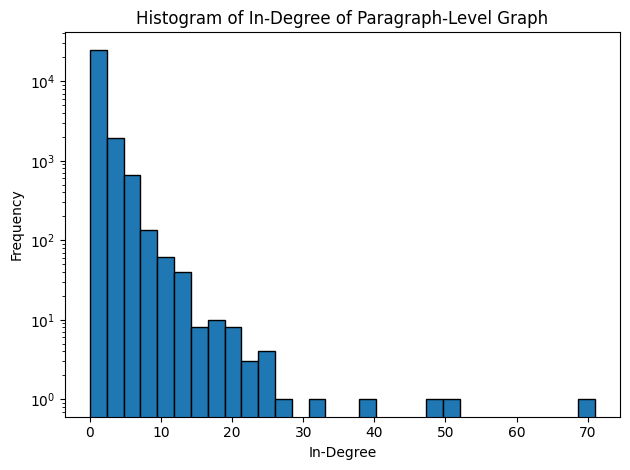

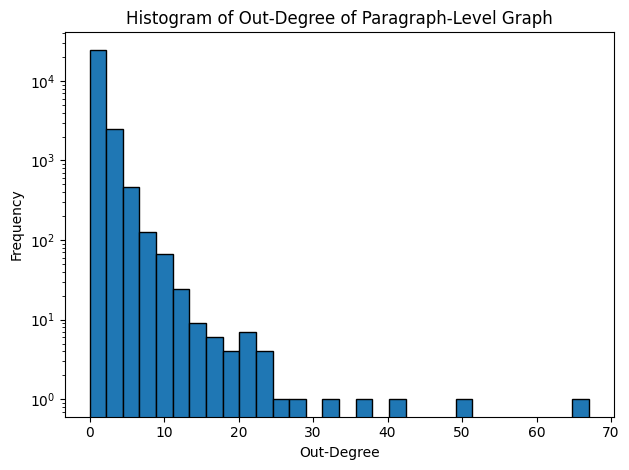

In [122]:
# Make a histogram over in_degree and out_degree
plt.figure()
plt.hist(par_deg_df["in_degree"], bins=30, edgecolor='black')
plt.title("Histogram of In-Degree of Paragraph-Level Graph")
plt.yscale("log")
plt.xlabel("In-Degree")
plt.ylabel("Frequency")
plt.tight_layout()

# Make a histogram over in_degree and out_degree
plt.figure()
plt.hist(par_deg_df["out_degree"], bins=30, edgecolor='black')
plt.title("Histogram of Out-Degree of Paragraph-Level Graph")
plt.yscale("log")
plt.xlabel("Out-Degree")
plt.ylabel("Frequency")
plt.tight_layout()

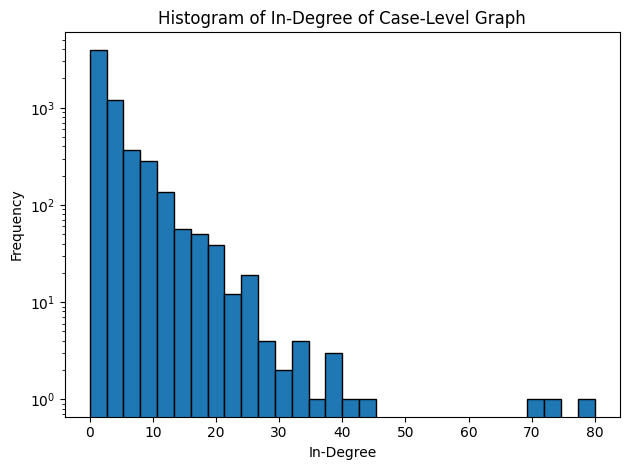

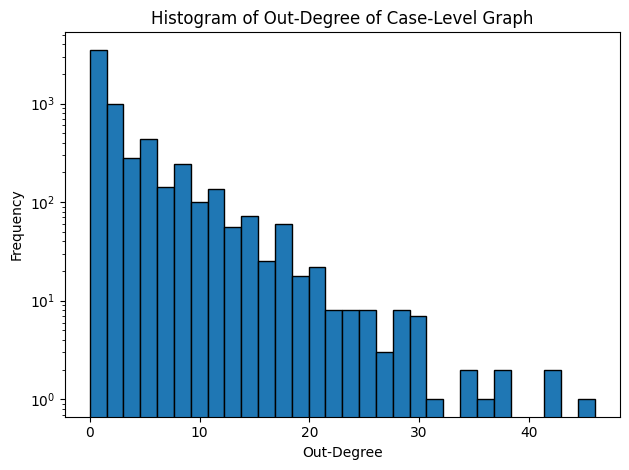

In [121]:
# Make a histogram over in_degree and out_degree
plt.figure()
plt.hist(case_deg_df["in_degree"], bins=30, edgecolor='black')
plt.title("Histogram of In-Degree of Case-Level Graph")
plt.yscale("log")
plt.xlabel("In-Degree")
plt.ylabel("Frequency")
plt.tight_layout()

# Make a histogram over in_degree and out_degree
plt.figure()
plt.hist(case_deg_df["out_degree"], bins=30, edgecolor='black')
plt.title("Histogram of Out-Degree of Case-Level Graph")
plt.yscale("log")
plt.xlabel("Out-Degree")
plt.ylabel("Frequency")
plt.tight_layout()

In [110]:
# Build CELEX -> TITLE mapping (prefer FROM then TO)
title_map = {}
for _, r in df[["CELEX_FROM","TITLE_FROM"]].drop_duplicates().iterrows():
    title_map[r["CELEX_FROM"]] = r["TITLE_FROM"]
for _, r in df[["CELEX_TO","TITLE_TO"]].drop_duplicates().iterrows():
    title_map.setdefault(r["CELEX_TO"], r["TITLE_TO"])

# Enrich case-level tables with titles
case_top_in["CELEX"] = case_top_in["node"]
case_top_in["TITLE"] = case_top_in["CELEX"].map(title_map)
case_top_out["CELEX"] = case_top_out["node"]
case_top_out["TITLE"] = case_top_out["CELEX"].map(title_map)

# Save enriched versions
case_top_in_enriched = case_top_in[["CELEX","TITLE","in_degree","out_degree","total_degree"]]
case_top_out_enriched = case_top_out[["CELEX","TITLE","in_degree","out_degree","total_degree"]]


# Enrich paragraph-level tables with CELEX, NUMBER and titles
def split_par(node_str):
    # Expect format "CELEX§NUMBER"
    parts = str(node_str).split("§", 1)
    if len(parts) == 2:
        return parts[0], parts[1]
    return node_str, ""
    
for tbl_name in ["par_top_in", "par_top_out"]:
    tbl = globals()[tbl_name]
    celex_num = tbl["node"].apply(split_par).tolist()
    celex = [c for c, n in celex_num]
    num = [n for c, n in celex_num]
    tbl["CELEX"] = celex
    tbl["PARAGRAPH"] = num
    tbl["TITLE"] = tbl["CELEX"].map(title_map)

par_top_in_enriched = par_top_in[["CELEX","PARAGRAPH","TITLE","in_degree","out_degree","total_degree"]]
par_top_out_enriched = par_top_out[["CELEX","PARAGRAPH","TITLE","in_degree","out_degree","total_degree"]]

# Display enriched tables
# display_dataframe_to_user("Case-level: top 15 by in-degree (with titles)", case_top_in_enriched)
# display_dataframe_to_user("Case-level: top 15 by out-degree (with titles)", case_top_out_enriched)
# display_dataframe_to_user("Paragraph-level: top 15 by in-degree (with titles)", par_top_in_enriched)
# display_dataframe_to_user("Paragraph-level: top 15 by out-degree (with titles)", par_top_out_enriched)


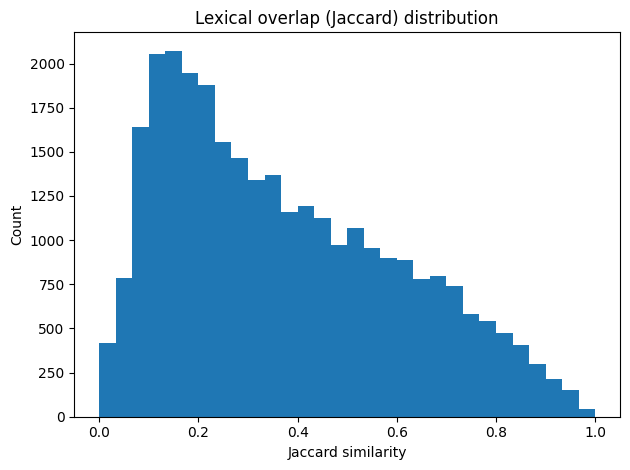

,mean,median,p10,p90
0,0.370864,0.324324,0.101869,0.719512


In [119]:
import numpy as np
from nltk.tokenize import word_tokenize

sub = df.dropna(subset=["TEXT_FROM", "TEXT_TO"]).copy()

# Tokenization using nltk
def tokenize(s: str) -> list[str]:
    return [t.lower() for t in word_tokenize(s) if t.isalpha() and len(t) > 2]

def jaccard(a, b):
    sa, sb = set(a), set(b)
    if not sa and not sb:
        return np.nan
    return len(sa & sb) / len(sa | sb)

# Compute Jaccard similarity per edge (this is a rough lexical measure)
jac = []
for t_from, t_to in zip(sub["TEXT_FROM"], sub["TEXT_TO"]):
    tf = tokenize(t_from)
    tt = tokenize(t_to)
    jac.append(jaccard(tf, tt))

sub["jaccard"] = jac

# Plot histogram
plt.figure()
plt.hist([x for x in sub["jaccard"].values if pd.notna(x)], bins=30)
plt.title("Lexical overlap (Jaccard) distribution")
plt.xlabel("Jaccard similarity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

summary = {
    "mean": float(np.nanmean(sub["jaccard"])) if len(sub) else np.nan,
    "median": float(np.nanmedian(sub["jaccard"])) if len(sub) else np.nan,
    "p10": float(np.nanpercentile(sub["jaccard"], 10)) if len(sub) else np.nan,
    "p90": float(np.nanpercentile(sub["jaccard"], 90)) if len(sub) else np.nan,
}

pd.DataFrame([summary])